In [1]:
%load_ext autoreload
%autoreload 2

In [43]:
import h5py, os, tqdm, glob, scipy
# os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.49'

import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
import jax_cosmo as jc

import optax
from optax.losses import huber_loss
from flax import nnx
import orbax.checkpoint as ocp
import jraph

import diffrax
from diffrax import diffeqsolve, ODETerm, LeapfrogMidpoint, PIDController, SaveAt, ConstantStepSize

import jaxpm
from jaxpm import camels, plotting, hpm, nn, graph, diagnostics, objectives
from jaxpm.painting import cic_paint, cic_read, compensate_cic
from jaxpm.kernels import fftk, gradient_kernel, invlaplace_kernel, longrange_kernel, invnabla_kernel
from jaxpm.utils import power_spectrum, cross_correlation_coefficients
from jaxpm.nn import MLP, ScaleConditionedCNN
from jaxpm.objectives import ParticleLoss

print(jax.default_backend())

gpu


# configuration

In [3]:
parts_per_dim = 64
mesh_per_dim = parts_per_dim
# mesh_per_dim = 2 * parts_per_dim

# parts_per_dim = 128
# mesh_per_dim = parts_per_dim

# parts_per_dim = None
# mesh_per_dim = 256

mesh_shape = [mesh_per_dim] * 3
box_size = [float(mesh_per_dim)] * 3

# CAMELS

In [4]:
CODE = "SIMBA"
# CODE = "ASTRID"
# CODE = "IllustrisTNG"

train_dict = camels.load_CV_snapshots(
    "CV_0",
    mesh_per_dim,
    parts_per_dim,
    i_snapshots=None,
    CAMELS="/pscratch/sd/a/athomsen/flatiron/CAMELS",
    CODE=CODE,
)

vali_dict = camels.load_CV_snapshots(
    "CV_1",
    mesh_per_dim,
    parts_per_dim,
    i_snapshots=None,
    CAMELS="/pscratch/sd/a/athomsen/flatiron/CAMELS",
    CODE=CODE,
)

Loaded /pscratch/sd/a/athomsen/flatiron/CAMELS/h5/SIMBA/CV/CV_0/parts=64,mesh=64.h5
Loaded /pscratch/sd/a/athomsen/flatiron/CAMELS/h5/SIMBA/CV/CV_1/parts=64,mesh=64.h5


In [5]:
vcic_paint = jax.vmap(cic_paint, in_axes=(None,0,None))
vcic_read = jax.vmap(cic_read, in_axes=(0,0))

In [6]:
def train_step_base(model, optimizer, loss_fn_wrapper):
    loss, grads = nnx.value_and_grad(loss_fn_wrapper)(model)
    optimizer.update(grads)

    squared_sum = jax.tree_util.tree_reduce(
            lambda x, y: x + jnp.sum(y**2),
            grads,
            0.0
        )
    grad_norm = jnp.sqrt(squared_sum)

    return loss, grad_norm
    

@nnx.jit(
    static_argnames=(
        "model_type", 
        "pressure_architecture", 
        "w_pos", 
        "w_vel", 
        "w_cls", 
        "w_cross", 
        "w_snapshot"
    )
)
def train_step_particle(
    optimizer,
    y0,
    t0,
    ref_t, 
    ref_poss, 
    ref_vels=None,
    ref_cls=None,
    ref_deltas=None,
    gravity_model=None,
    pressure_model=None,
    # static
    model_type="pressure",
    pressure_architecture="mlp", 
    w_pos=1.0,
    w_vel=0.0,
    w_cls=0.0,
    w_cross=0.0,
    w_snapshot=0.0,
):
    """dynamic snapshot range as passed"""

    if model_type == "pressure":
        def loss_fn_wrapper(model):
            return particle_loss_fn(
                y0, 
                t0,
                ref_t, 
                ref_poss, 
                ref_vels,
                ref_cls, 
                ref_deltas,
                gravity_model=gravity_model, 
                pressure_model=model, 
                species="gas",
                pressure_architecture=pressure_architecture, 
                w_pos=w_pos,
                w_vel=w_vel,
                w_cls=w_cls,
                w_cross=w_cross,
                w_snapshot=w_snapshot,
            )

        return train_step_base(pressure_model, optimizer, loss_fn_wrapper)

    elif model_type == "gravity":
        def loss_fn_wrapper(model):
            return particle_loss_fn(
                y0, 
                t0,
                ref_t, 
                ref_poss, 
                ref_vels,
                ref_cls, 
                ref_deltas,
                gravity_model=model, 
                pressure_model=pressure_model, 
                species="dm",
                pressure_architecture=pressure_architecture,
                w_pos=w_pos,
                w_vel=w_vel,
                w_cls=w_cls,
                w_cross=w_cross,
                w_snapshot=w_snapshot,
            )

        return train_step_base(gravity_model, optimizer, loss_fn_wrapper)
    
@nnx.jit(static_argnames=("architecture",))
def train_step_field(model, optimizer, y0, ts, ref_rho, ref_cls, architecture="cnn"):
    """dynamic snapshot range as passed"""
    
    def loss_fn_wrapper(model):
        return field_loss_fn(model, y0, ts, ref_rho, ref_cls, architecture, eps=1e-8)

    return train_step_base(model, optimizer, loss_fn_wrapper)

In [7]:
# dt0 = 0.001
# dt0 = 0.1
dt0 = 0.01
# dt0 = 0.005

scales = train_dict["scales"]
print(np.diff(scales))
assert np.all(np.diff(scales) > dt0)

# edges = graph.get_edges(train_dict["gas_poss"], scales, k=4)

def solve_ode(y0, t0, ts, gravity_model, pressure_model, architecture, training=True):
    ode = ODETerm(
        hpm.get_hpm_network_ode_fn(
            mesh_per_dim, 
            cosmo, 
            gravity_model=gravity_model, 
            pressure_model=pressure_model, 
            gas_architecture=architecture, 
            training=training,
            # precomputed_edges=edges,
        )
    )

    res = diffeqsolve(
            terms=ode,
            solver=LeapfrogMidpoint(),
            t0=t0,
            t1=ts[-1],
            dt0=dt0,
            y0=y0,
            saveat=SaveAt(ts=ts),
            max_steps=1000,
            stepsize_controller=ConstantStepSize(),
        )
    res = res.ys

    return res


[0.02380952 0.03333333 0.02222222 0.02777778 0.01224106 0.01284044
 0.01346916 0.01412867 0.01482047 0.01554614 0.01630734 0.01710582
 0.0179434  0.01882198 0.01974359 0.02071031 0.02172438 0.0227881
 0.0239039  0.02507434 0.02630208 0.02758995 0.02894087 0.03035793
 0.03184439 0.03340362 0.03503921 0.03675488 0.03855455 0.04044235
 0.04242258 0.04449977 0.04667867]


# loss

### CAMELS ground truth

In [8]:
# general
cosmo = train_dict["cosmo"]
scales = train_dict["scales"]

# particles
dm_poss = train_dict["dm_poss"]
dm_vels = train_dict["dm_vels"]

gas_poss = train_dict["gas_poss"]
gas_vels = train_dict["gas_vels"]

# fields
dm_mass = cosmo.Omega_c / (cosmo.Omega_b + cosmo.Omega_c)
gas_mass = 1 - dm_mass

rhos_dm = vcic_paint(jnp.zeros(mesh_shape), dm_poss, dm_mass)
deltas_dm = rhos_dm/rhos_dm.mean() - 1

rhos_gas = vcic_paint(jnp.zeros(mesh_shape), gas_poss, gas_mass)
deltas_gas = rhos_gas/rhos_gas.mean() - 1

# power spectrum
_, cls_dm = objectives.vpower_spectrum(deltas_dm)
_, cls_gas = objectives.vpower_spectrum(deltas_gas)

### particle-level

In [9]:
def particle_loss_fn(
    y0,
    t0,
    ref_t, 
    ref_poss,
    ref_vels=None,
    ref_cls=None,
    ref_deltas=None,
    species="gas",
    gravity_model=None, 
    pressure_model=None, 
    # static
    pressure_architecture="mlp", 
    w_pos=1.0,
    w_vel=0.0,
    w_cls=0.0,
    w_cross=0.0,
    w_snapshot=0.0,
    eps=1e-8,
    # w_snapshot=1/jnp.maximum(scales[:, jnp.newaxis]**3, eps),
):
    print("using particle loss")
    
    # integrate
    res = solve_ode(y0, t0, ref_t, gravity_model, pressure_model, pressure_architecture)
    if species == "dm":
        res_poss, res_vels = res[0], res[1]
    elif species == "gas":
        res_poss, res_vels = res[2], res[3]
    else:
        raise NotImplementedError

    loss = objectives.particle_loss(
        mesh_per_dim,
        res_poss,
        res_vels,
        ref_poss,
        ref_vels,
        ref_cls,
        ref_deltas,
        w_pos,
        w_vel,
        w_cls,
        w_cross,
        w_snapshot,
        eps,
    )
    
    return loss


In [ ]:
# class ParticleLossWrapper():
#     def __init__(
#         species="gas",
#         pressure_architecture="mlp", 
#         w_pos=1.0,
#         w_vel=0.0,
#         w_cls=0.0,
#         w_cross=0.0,
#         w_snapshot=0.0,
#         eps=1e-8,
#     ):

#     def __call__(
#         y0,
#         t0,
#         ref_t, 
#         ref_poss,
#         ref_vels=None,
#         ref_cls=None,
#         ref_deltas=None,
#         species="gas",
#         gravity_model=None, 
#         pressure_model=None, 
#     ):
#         print("using particle loss")
        
#         # integrate
#         res = solve_ode(y0, t0, ref_t, gravity_model, pressure_model, pressure_architecture)
#         if species == "dm":
#             res_poss, res_vels = res[0], res[1]
#         elif species == "gas":
#             res_poss, res_vels = res[2], res[3]
#         else:
#             raise NotImplementedError
    
#         loss = objectives.particle_loss(
#             mesh_per_dim,
#             res_poss,
#             res_vels,
#             ref_poss,
#             ref_vels,
#             ref_cls,
#             ref_deltas,
#             w_pos,
#             w_vel,
#             w_cls,
#             w_cross,
#             w_snapshot,
#             eps,
#         )

    

### field-level

In [10]:
# def field_loss_fn(model, y0, ts, ref_rho, ref_cls, architecture, eps=1e-8):
#     print("using field loss")
    
#     res = solve_ode(model, y0, ts, architecture)
#     gas_poss = res[2]%mesh_per_dim
#     gas_vels = res[3]

#     res_rho = vcic_paint(jnp.zeros(mesh_shape), gas_poss, gas_mass)
#     rho_loss = (res_rho - ref_rho)**2
#     # rho_loss /= jnp.maximum(scales.reshape(-1,1,1,1)**2, eps)
#     rho_loss = jnp.mean(rho_loss)

#     kbins, res_cls = vpower_spectrum(res_rho)
#     k = kbins[0]
#     k_min, k_cutoff = k[0], k[int(0.2*len(k))]
#     k_weights = jnp.expand_dims(jnp.exp(-(k - k_min) / k_cutoff), 0)

#     cl_loss = jnp.sum(((res_cls/jnp.maximum(ref_cls, eps) - 1)*k_weights)**2, axis=-1)
#     # cl_loss /= jnp.maximum(scales[:,jnp.newaxis]**3, eps)
#     cl_loss = jnp.mean(cl_loss)
        
#     return rho_loss + 0.1 * cl_loss
    

In [11]:
# def field_loss_fn(model, architecture):
#     res = solve_ode_diffrax(model, architecture)
#     gas_poss = res[2]%mesh_per_dim

#     rho = vcic_paint(jnp.zeros(mesh_shape), gas_poss, gas_mass)
        
#     eps = 1e-5
#     # rho_loss = jnp.mean((jnp.log1p(rho + eps) - jnp.log1p(ref_rho + eps))**2)
#     # rho_loss = jnp.mean((jnp.log10(rho - ref_rho + eps))**2)
    
#     rho_loss = jnp.mean(jnp.sum((rho - ref_rho)**2, axis=(1,2,3)))

#     # _, res_cls = vpower_spectrum(res_rho)
#     # cl_loss = jnp.mean(jnp.sum((res_cls/ref_cls - 1)**2, axis=-1))
    
#     return rho_loss
#     # return rho_loss + 0.1 * cl_loss


In [12]:
# def field_loss_fn(model, architecture):
#     res = solve_ode_diffrax(model, architecture)
#     gas_poss = res[2]%mesh_per_dim
    
#     rho = vcic_paint(jnp.zeros(mesh_shape), gas_poss, gas_mass)
    
#     eps = 1e-8
#     log_rho = jnp.log10(rho + eps)
#     log_ref_rho = jnp.log10(ref_rho + eps)
#     # log_loss = jnp.mean(jnp.sum((log_rho - log_ref_rho)**2, axis=(1,2,3)))
#     log_loss = jnp.mean((log_rho - log_ref_rho)**2)
        
#     return log_loss

# fit gravity correction

In [18]:
i_plots = range(0, 32+8, 8)

In [19]:
gravity_model = nn.NeuralSplineFourierFilterNNX(n_knots=8, d_latent=16, rngs=nnx.Rngs(0))

In [20]:
# see https://flax.readthedocs.io/en/latest/guides/checkpointing.html
checkpoint_file = os.path.join(os.getcwd(), f"checkpoints/gravity_fourier_spline_parts={parts_per_dim},mesh={mesh_per_dim}.jx")
checkpointer = ocp.StandardCheckpointer()

try:
    abstract_model = nnx.eval_shape(lambda: gravity_model)
    graphdef, abstract_params = nnx.split(abstract_model)
    
    params = checkpointer.restore(checkpoint_file, abstract_params)
    gravity_model = nnx.merge(graphdef, params)
    print(f"successfully restored model from {checkpoint_file}")
except:
    print("failed to load model")

successfully restored model from /global/u2/a/athomsen/flatiron/JaxPM/dev/hpm/sims/checkpoints/gravity_fourier_spline_parts=64,mesh=64.jx


/global/common/software/des/athomsen/flatiron/lib/python3.11/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1269: UserWarning: Sharding info not provided when restoring. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


## training

In [16]:
total_steps = 300
learning_rate = 1e-3
# learning_rate = optax.cosine_decay_schedule(
#     init_value=1e-3, 
#     decay_steps=total_steps, 
#     alpha=0.1
# )
clip_norm = 1

gravity_optimizer = nnx.ModelAndOptimizer(
    gravity_model,
    optax.chain(
        optax.clip_by_global_norm(clip_norm),
        optax.adam(learning_rate)
    )
)

losses = []
grad_norms = []

In [21]:
# # evaluating the loss for all snapshots is computationally feasible
# for i in (pbar := tqdm.tqdm(range(total_steps))):
#     i0 = 0
#     y0 = (dm_poss[i0], dm_vels[i0], gas_poss[i0], gas_vels[i0])
#     t0 = scales[i0]
    
#     loss, grad_norm = train_step_particle(
#         gravity_optimizer, 
#         y0, 
#         t0,
#         scales,
#         ref_poss=dm_poss, 
#         ref_cls=cls_dm,
#         ref_deltas=deltas_dm,
#         gravity_model=gravity_model,
#         pressure_model=None,
#         model_type="gravity",
#         w_pos=1.0,
#         w_cls=0.1,
#         # w_cross=0.1,
#         # w_cross=1.0,
#     )

#     losses.append(loss)
#     pbar.set_description(f"Loss: {loss:.4f}")

# fig, ax = plt.subplots()
# ax.plot(losses)
# ax.set(yscale="log")

In [22]:
# _, params = nnx.split(gravity_model)
# checkpointer.save(checkpoint_file, params, force=True)

dark matter and gas
dark matter and gas
dark matter and gas
dark matter and gas
Using learned correction to the gravitational potential
dark matter and gas
Using learned correction to the gravitational potential
dark matter and gas
Using learned correction to the gravitational potential


100%|██████████| 5/5 [00:11<00:00,  2.37s/it]


dark matter and gas
dark matter and gas
dark matter and gas
dark matter and gas
Using learned correction to the gravitational potential
dark matter and gas
Using learned correction to the gravitational potential
dark matter and gas
Using learned correction to the gravitational potential


100%|██████████| 5/5 [00:11<00:00,  2.33s/it]


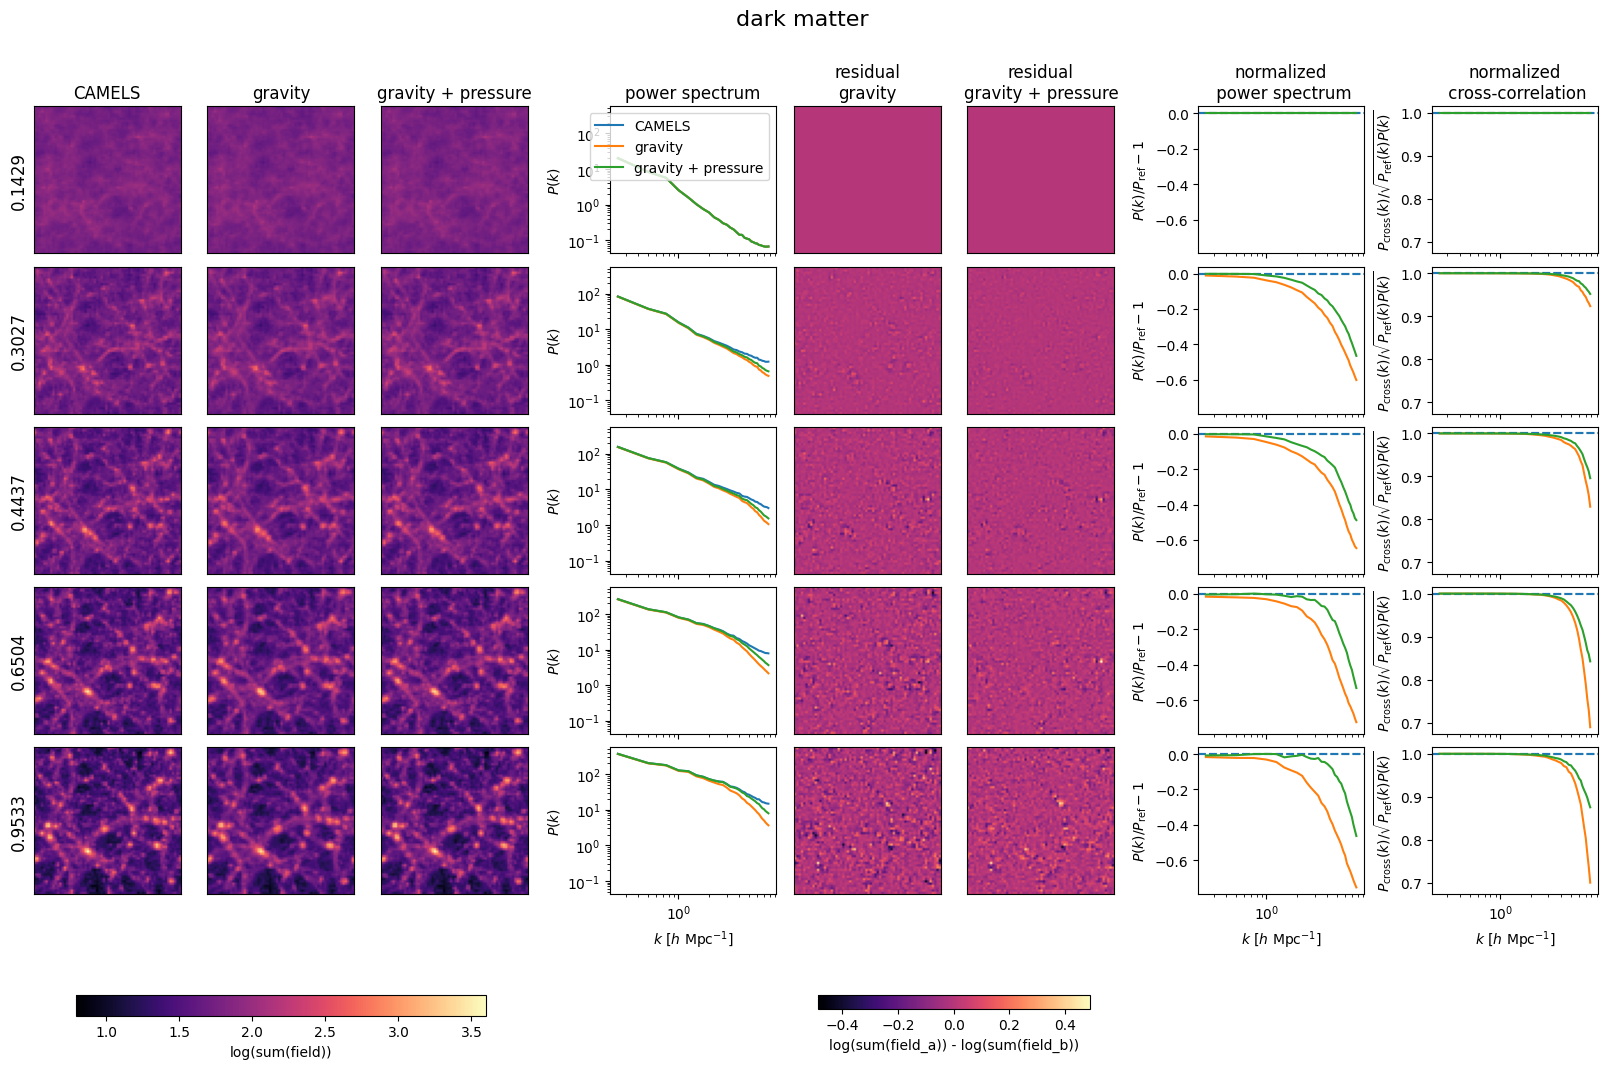

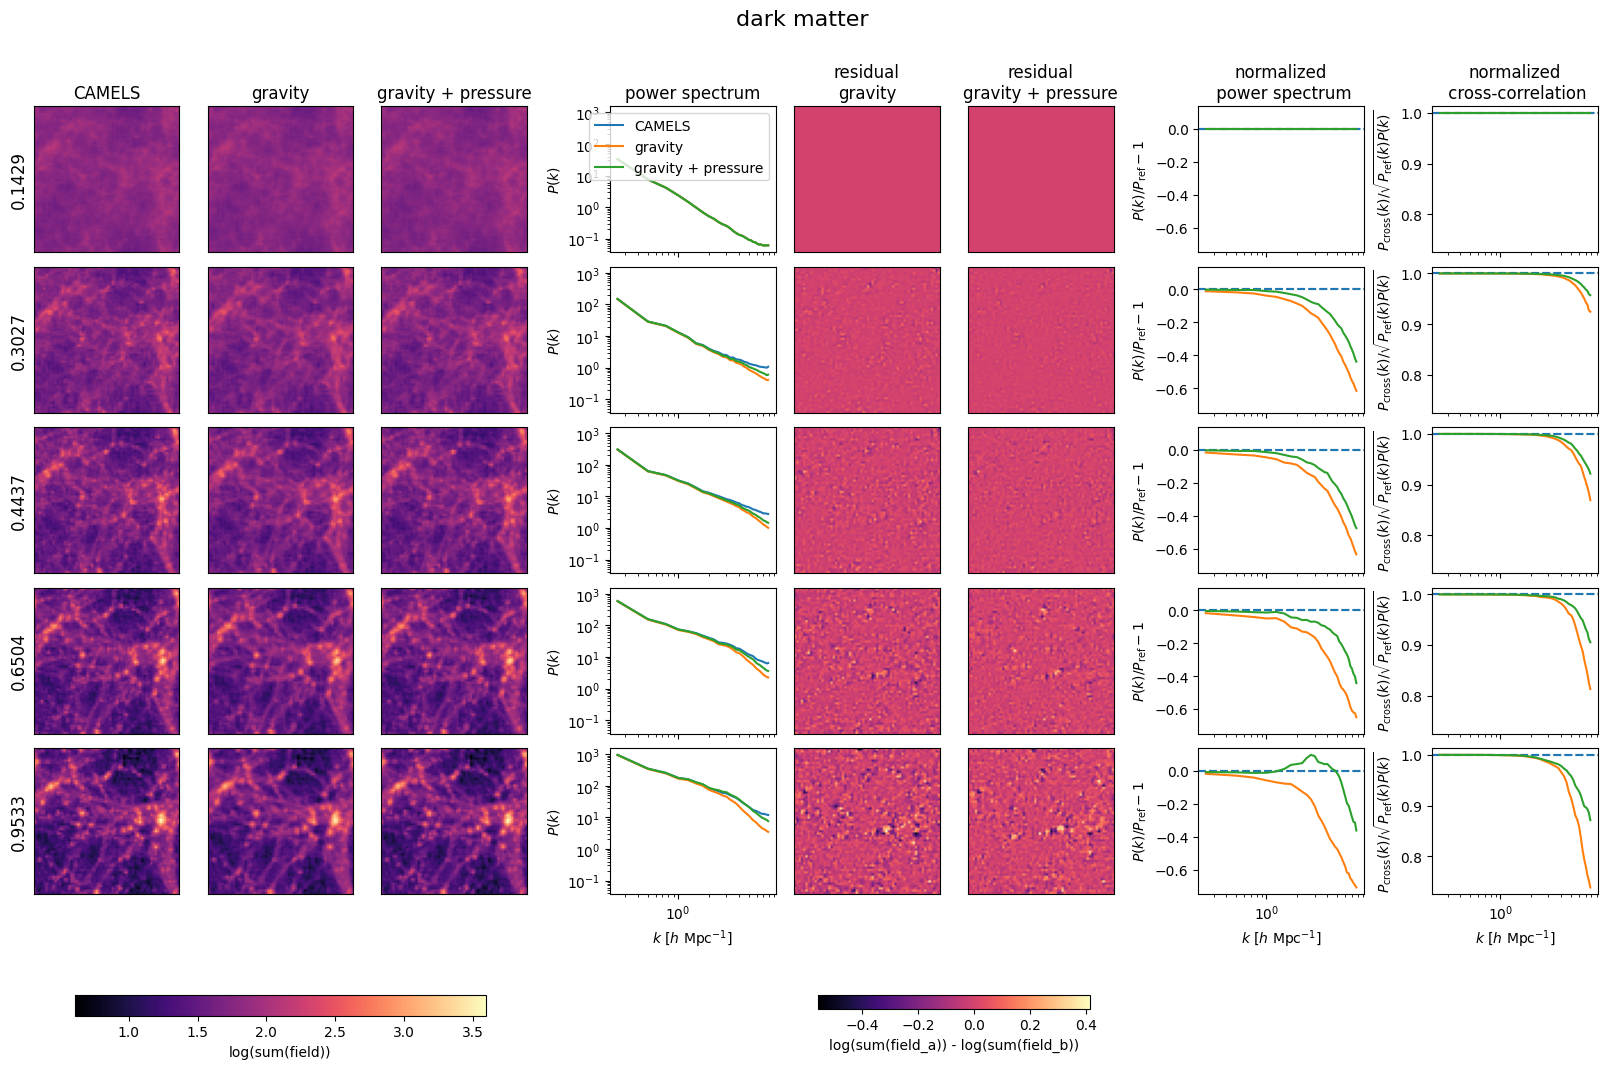

In [23]:
for camels_dict in [train_dict, vali_dict]:
    diagnostics.run_simulations(
        camels_dict,
        mesh_per_dim,
        gravity_model=gravity_model, 
        dt0=dt0,
        # i_snapshots=None,
        i_snapshots=i_plots,
        # i_snapshots=i_snapshots,
        # i_snapshots = range(1, 33+8, 8),
        # i_snapshots = range(1, 33+4, 4),
        plot_dm=True,
        plot_gas=False,
    )

# fit pressure correction

### MLP

In [24]:
pressure_model = MLP(
    d_in=5,
    d_out=1, 
    # d_hidden=16, 
    d_hidden=64, 
    # d_hidden=128,
    # d_hidden=256,
    n_hidden=4, 
    # n_hidden=2, 
    # dropout_rate=0.01,
    dropout_rate=0.0,
    rngs=nnx.Rngs(0),
    norm_type="layer",
    # norm_type="batch",
    activation=jax.nn.swish,
)
architecture = "mlp"

In [ ]:
particle_loss = ParticleLoss(
    mesh_per_dim,
    w_pos=1.0,
    w_vel=0.0,
    w_cls=0.0,
    w_cross=0.0,
    w_snapshot=0.0,
    eps=1e-8,
)

### CNN

In [25]:
# model = ScaleConditionedCNN(
#     d_in=4 + latent_dim, 
#     d_out=1 + latent_dim,
#     d_hidden=64,
#     # d_hidden=128,
#     # d_hidden=256,
#     # n_hidden=4,
#     n_hidden=4,
#     kernel_size=(3, 3, 3),
#     rngs=nnx.Rngs(0),
#     norm_type="layer",
#     activation=jax.nn.swish,
# )

# architecture = "cnn"

## training

In [31]:
def train_step_wrapper(i0=0, i_loss=None):
    y0 = (dm_poss[i0], dm_vels[i0], gas_poss[i0], gas_vels[i0])
    t0 = scales[i0]
    
    if all_steps := (i_loss is None):
        i_loss = np.arange(0, len(scales))

    if architecture in ["mlp"]:
        loss, grad_norm = train_step_particle(
            pressure_optimizer, 
            y0, 
            t0,
            ref_t=scales[i_loss], 
            ref_poss=gas_poss[i_loss], 
            ref_cls=cls_gas[i_loss],
            pressure_model=pressure_model,
            gravity_model=gravity_model,
            pressure_architecture=architecture,
            model_type="pressure",
            w_cls=0.1,
        )
    elif architecture in ["cnn"]:
        loss, grad_norm = train_step_field(
            y0, 
            scales[i_step], 
            rho_gas[i_step],
            cls_gas[i_step],
            pressure_optimizer, 
            pressure_model=pressure_model,
            gravity_model=gravity_model,
            model_type="pressure",
        )
    else:
        raise NotImplementedError

    losses.append(float(loss))
    grad_norms.append(float(grad_norm))
    if all_steps:
        pbar.set_description(f"All steps, Loss: {loss:.4e}, Grad norm: {grad_norm:.4e}")
    else:
        pbar.set_description(f"{i_loss}, Loss: {loss:.4e}, Grad norm: {grad_norm:.4e}")
    

def plot_training(losses, grad_norms):
    fig, ax = plt.subplots(figsize=(6,10), nrows=2, sharex=True)
    ax[0].plot(losses)
    ax[0].set(yscale="log", title="loss")
    
    ax[1].plot(grad_norms)
    ax[1].set(yscale="log", title="norm(grad)")

In [32]:
total_steps = 100

# learning_rate = 1e-3
# learning_rate = 5e-4
learning_rate = 1e-4
# learning_rate = optax.cosine_decay_schedule(
#     init_value=1e-4, 
#     decay_steps=total_steps, 
#     alpha=0.1
# )
# learning_rate = optax.warmup_cosine_decay_schedule(
#     init_value=1e-4,
#     peak_value=1e-3,
#     end_value=1e-5,
#     warmup_steps=total_steps//5,
#     decay_steps=total_steps - total_steps//5, 
# )
clip_norm = 1

pressure_optimizer = nnx.ModelAndOptimizer(
    pressure_model,
    optax.chain(
        optax.clip_by_global_norm(clip_norm),
        optax.adam(learning_rate)
        # optax.ema(decay=0.999),
        # optax.adamw(learning_rate, b1=0.95, b2= 0.9999, eps=1e-5)
        # optax.adamw(learning_rate, eps=1e-5)
    )
)

losses = []
grad_norms = []

In [33]:
i_loss = np.arange(-4, 0, dtype=int)
# i_loss = np.arange(-8, 0, dtype=int)
# i_loss = np.arange(0, 8, dtype=int)

## fixed snapshots

### all

All steps, Loss: 5.9531e+00, Grad norm: 2.3569e+02: 100%|██████████| 100/100 [02:40<00:00,  1.61s/it]


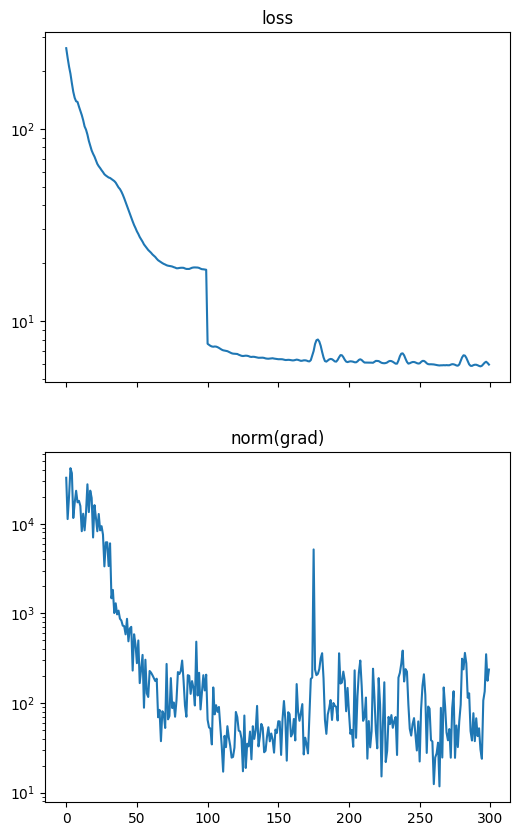

In [38]:
for i in (pbar := tqdm.tqdm(range(total_steps))):
    train_step_wrapper(i0=0)
plot_training(losses, grad_norms)

### subset

In [39]:
# for i in (pbar := tqdm.tqdm(range(total_steps))):
#     train_step_wrapper(i0=0, i_loss=i_loss)
# plot_training(losses, grad_norms)

In [40]:
# for i in (pbar := tqdm.tqdm(range(total_steps))):
#     train_step_wrapper(i_snapshots)
# plot_training(losses, grad_norms)

## random snapshots

### spaced

In [ ]:
# i_base = np.arange(0, 32, 4)
# i_delta = 6

# for i in (pbar := tqdm.tqdm(range(total_steps))):
#     i_shift = np.random.randint(0, i_delta)
#     i_step = i_base + i_shift

#     train_step_wrapper(i_step)
# plot_training(losses, grad_norms)

### continuous

In [ ]:
# i_delta = 8

# for i in (pbar := tqdm.tqdm(range(total_steps))):
#     i_rand = np.random.randint(0, len(scales) - i_delta)
#     i_step = np.arange(i_rand, i_rand + i_delta)
    
#     train_step_wrapper(i_step)
# plot_training(losses, grad_norms)

### checkpointing

In [ ]:
# # see https://flax.readthedocs.io/en/latest/guides/checkpointing.html
# # checkpoint_file = os.path.join(os.getcwd(), "checkpoints/mlp_sim_v1_late_time.jx")
# # checkpoint_file = os.path.join(os.getcwd(), "checkpoints/mlp_sim_v2.jx")
# # checkpoint_file = os.path.join(os.getcwd(), "checkpoints/mlp_sim_illustris_v1.jx")
# checkpoint_file = os.path.join(os.getcwd(), "checkpoints/mlp_sim_v4_full.jx")
# checkpointer = ocp.StandardCheckpointer()
# print(os.getcwd())

In [ ]:
# _, params = nnx.split(model)
# checkpointer.save(checkpoint_file, params, force=True)

In [ ]:
# abstract_model = nnx.eval_shape(lambda: model)
# graphdef, abstract_params = nnx.split(abstract_model)

# params = checkpointer.restore(checkpoint_file, abstract_params)
# model = nnx.merge(graphdef, params)

# run the simulation

dark matter and gas
dark matter and gas
dark matter and gas
dark matter and gas
Using learned correction to the gravitational potential
Using learned pressure force
No latent variable
dark matter and gas
Using learned correction to the gravitational potential
Using learned pressure force
No latent variable
dark matter and gas
Using learned correction to the gravitational potential
Using learned pressure force
No latent variable


100%|██████████| 5/5 [00:11<00:00,  2.39s/it]


dark matter and gas
dark matter and gas
dark matter and gas
dark matter and gas
Using learned correction to the gravitational potential
Using learned pressure force
No latent variable
dark matter and gas
Using learned correction to the gravitational potential
Using learned pressure force
No latent variable
dark matter and gas
Using learned correction to the gravitational potential
Using learned pressure force
No latent variable


100%|██████████| 5/5 [00:12<00:00,  2.40s/it]


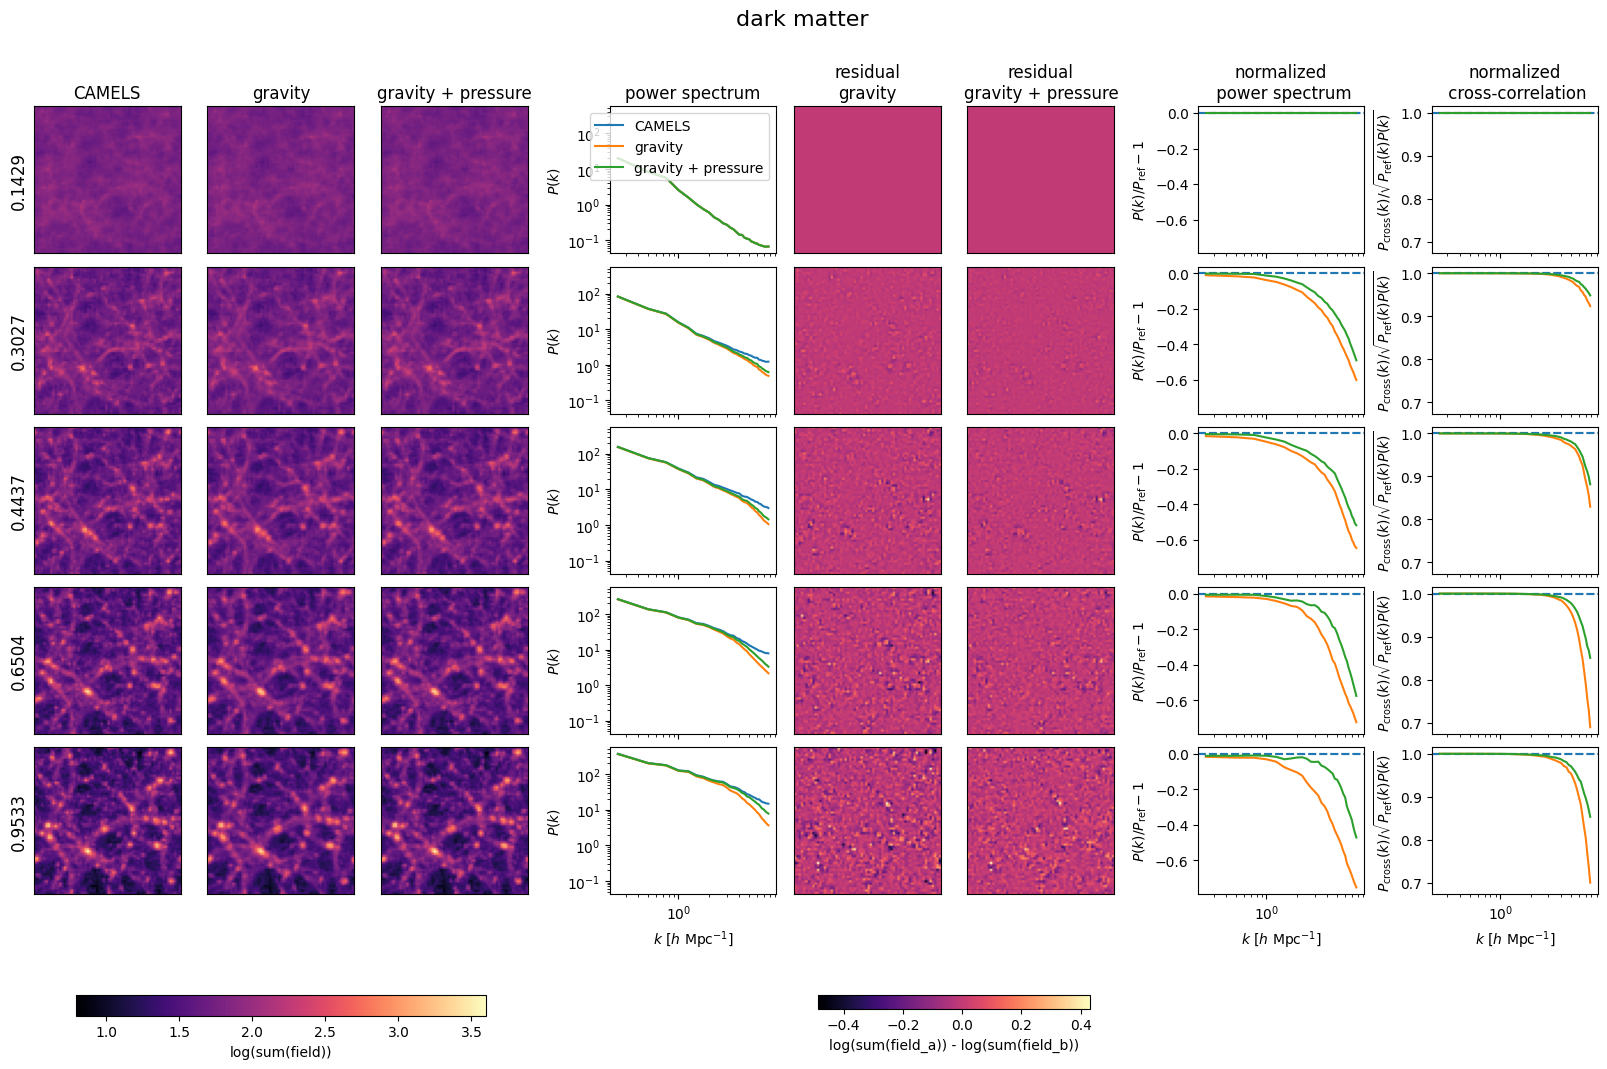

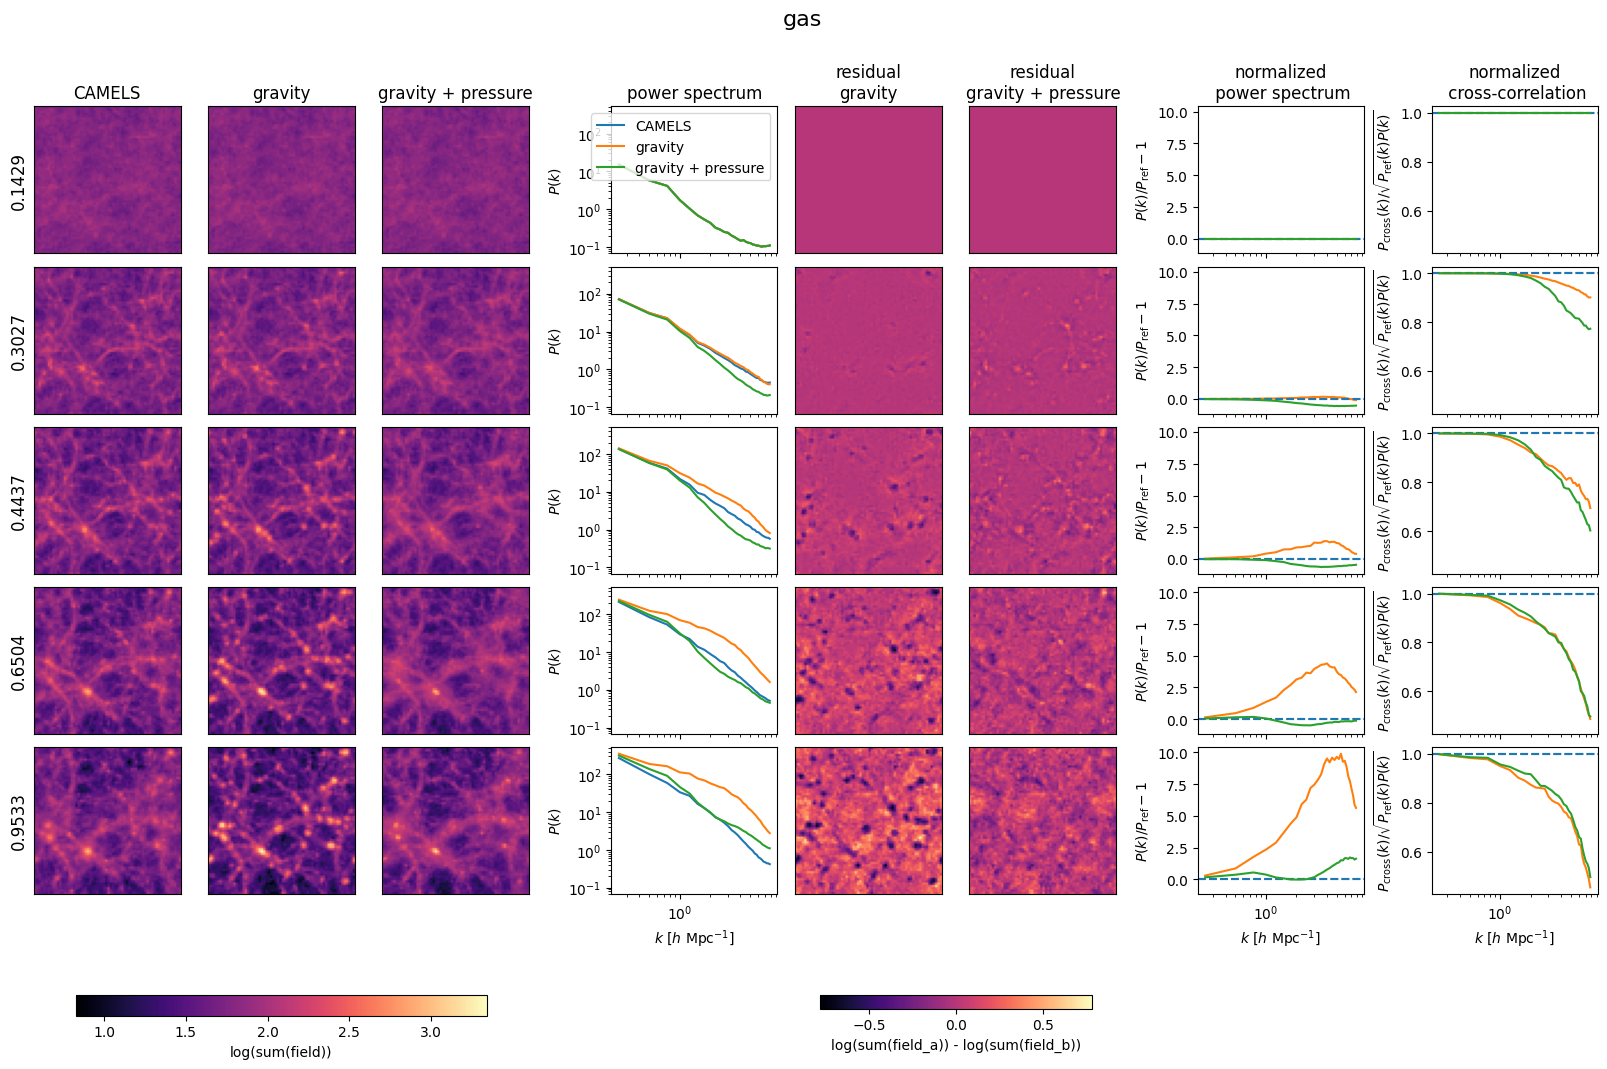

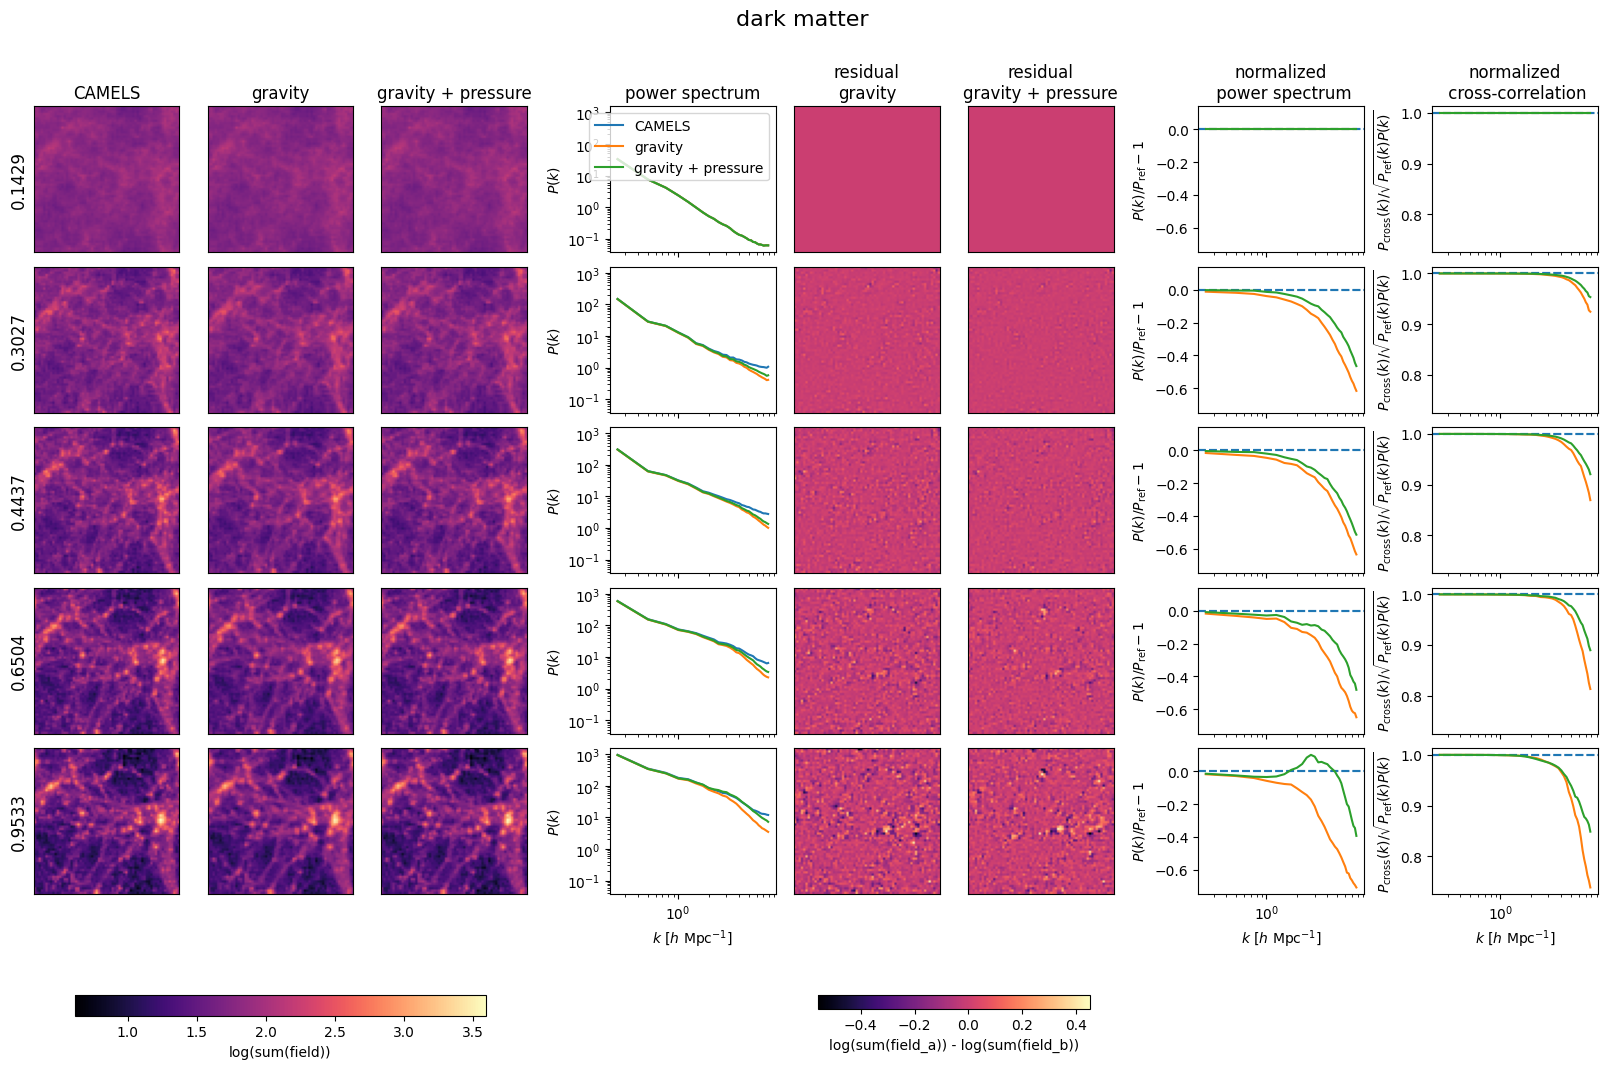

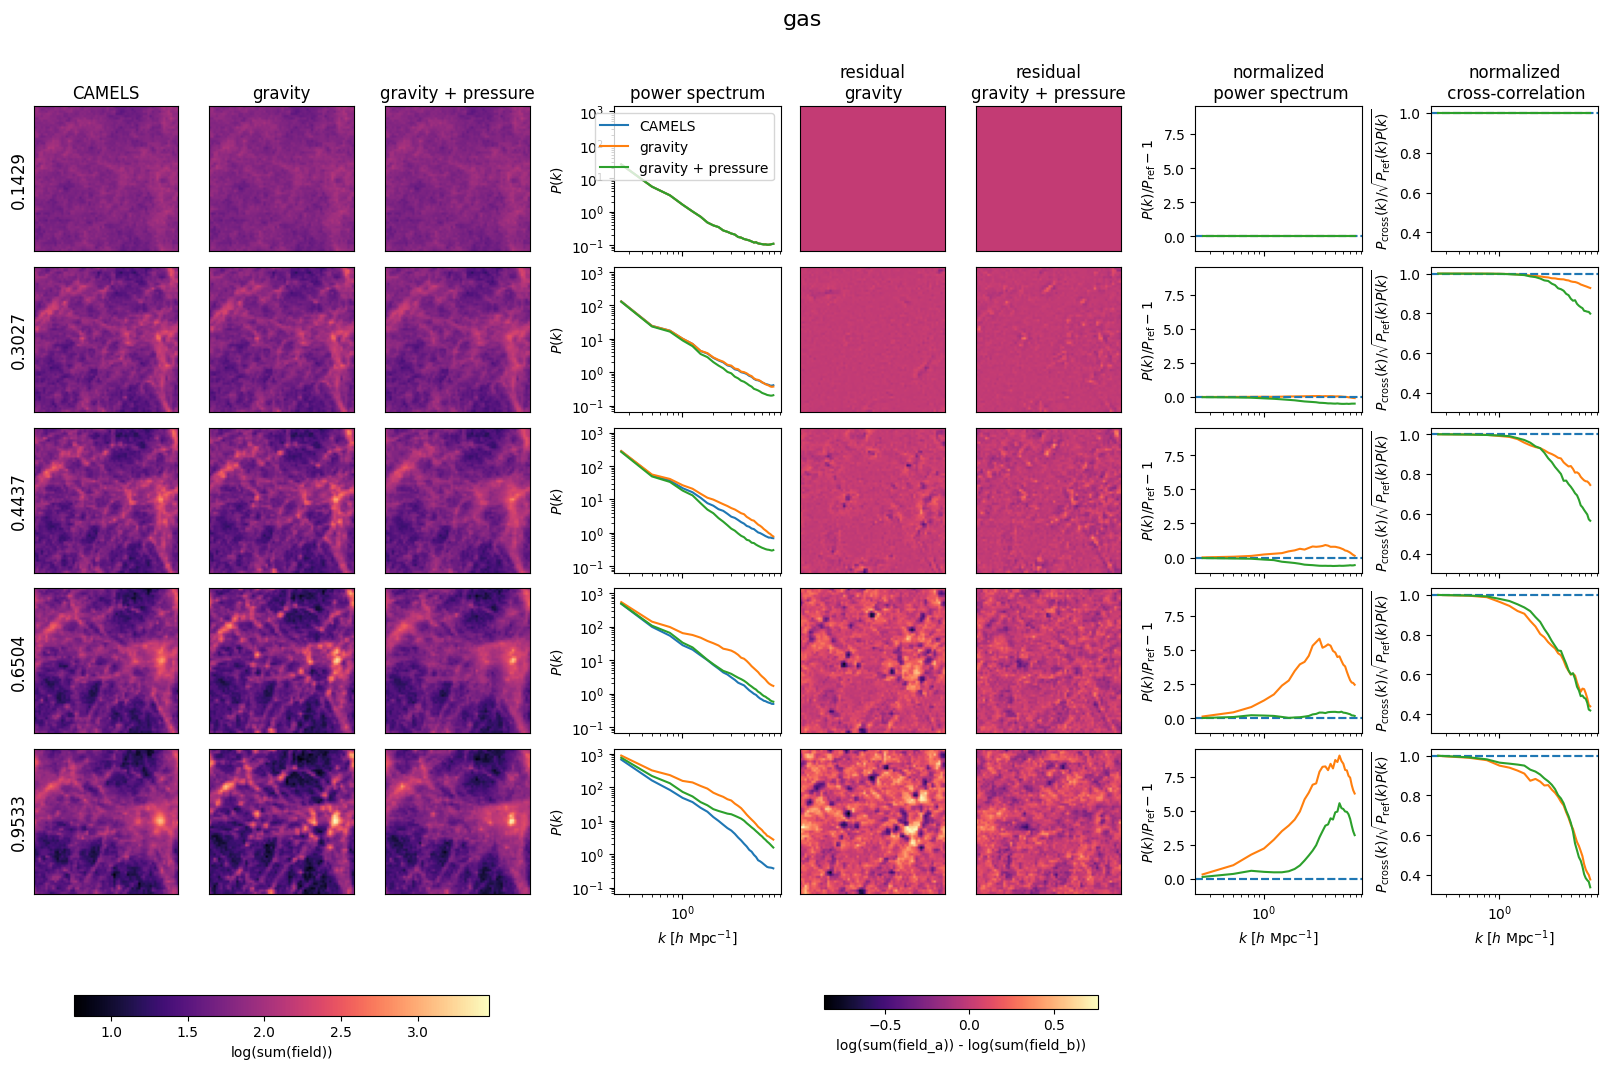

In [42]:
for camels_dict in [train_dict, vali_dict]:
    diagnostics.run_simulations(
        camels_dict,
        mesh_per_dim,
        gravity_model=gravity_model,
        pressure_model=pressure_model, 
        gas_architecture=architecture, 
        dt0=dt0,
        # i_snapshots=None,
        i_snapshots=i_plots,
        # i_snapshots=i_snapshots,
        # i_snapshots = range(1, 33+8, 8),
        # i_snapshots = range(0, 32+8, 8),
        # i_snapshots = range(1, 33+4, 4),
        plot_dm=True,
        plot_gas=True,
    )